In [10]:
import pandas as pd        # Biblioteca para manipulação e análise de dados em tabelas (DataFrames)
import numpy as np         # Biblioteca para cálculos numéricos e operações matemáticas
import matplotlib.pyplot as plt  # Biblioteca para criação de gráficos estáticos
import seaborn as sns      # Biblioteca para visualização estatística de dados
import plotly.express as px # Biblioteca para criação de gráficos interativos


In [11]:
#define um estilo visual padrão para os gráficos usando a biblioteca Seaborn
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [12]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

In [13]:
dados = pd.read_excel(
    file_path,
    sheet_name="dados"
)

In [14]:
quartis = pd.read_excel(
    file_path,
    sheet_name="QUARTIS"
)

In [15]:
dados.head()

,Data,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
0,1984-01-01,0.989776,0.518743,25.419519,211.801254
1,1984-01-02,0.166336,0.587044,26.399133,204.752853
2,1984-01-03,0.256648,0.419522,26.202539,217.430527
3,1984-01-04,0.000000,0.478503,26.720331,222.075912
4,1984-01-05,0.000000,0.374592,27.286249,220.100525


In [16]:
quartis

,Variável,Q1,Q2,Q3,Q4
0,Precipitação,0.00,0.58,3.84,53.14
1,Evapotranspiração,1.97,2.64,3.23,5.78
2,Temperatura Média,24.12,25.35,26.12,28.67
3,Radiação,165.28,186.89,205.97,257.56


In [17]:
dados.columns

Index(['Data', 'mm/dia - Precipitação', 'mm/dia - Evapotranspiração ',
       'C° - Temperatura Média', 'W/m² - Radiação'],
      dtype='str')

In [18]:
dados.shape

(11322, 5)

In [19]:
# Verificar os tipos de dados e a presença de valores nulos
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 11322 entries, 0 to 11321
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Data                         11322 non-null  datetime64[us]
 1   mm/dia - Precipitação        11322 non-null  float64       
 2   mm/dia - Evapotranspiração   11322 non-null  float64       
 3   C° - Temperatura Média       11322 non-null  float64       
 4   W/m² - Radiação              11322 non-null  float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 442.4 KB


In [20]:
# Checagem do escopo: existe coluna de município/cidade?
colunas_texto = [c for c in dados.columns if isinstance(c, str)]
colunas_municipio = [c for c in colunas_texto if any(k in c.lower() for k in ["municip", "cidade", "local", "estacao", "municí"]) ]

if colunas_municipio:
    print("Colunas que parecem identificar município/local:", colunas_municipio)
else:
    print("Nenhuma coluna de município/cidade encontrada. A base parece ser uma única série temporal (Data + variáveis).")

Nenhuma coluna de município/cidade encontrada. A base parece ser uma única série temporal (Data + variáveis).


In [21]:

# Converter a coluna "Data" para o tipo datetime

dados["Data"] = pd.to_datetime(dados["Data"], dayfirst=True)

In [22]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 11322 entries, 0 to 11321
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Data                         11322 non-null  datetime64[us]
 1   mm/dia - Precipitação        11322 non-null  float64       
 2   mm/dia - Evapotranspiração   11322 non-null  float64       
 3   C° - Temperatura Média       11322 non-null  float64       
 4   W/m² - Radiação              11322 non-null  float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 442.4 KB


In [23]:
#remover a coluna "Data" para focar apenas nas variáveis climáticas
variaveis_climaticas = dados.drop(columns=["Data"])

In [24]:
variaveis_climaticas.head()

,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
0,0.989776,0.518743,25.419519,211.801254
1,0.166336,0.587044,26.399133,204.752853
2,0.256648,0.419522,26.202539,217.430527
3,0.000000,0.478503,26.720331,222.075912
4,0.000000,0.374592,27.286249,220.100525


In [25]:
#obter uma visão geral das estatísticas descritivas das variáveis climáticas
variaveis_climaticas.describe()

,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
count,11322.000000,11322.000000,11322.000000,11322.000000
mean,2.829070,2.605321,25.173350,185.459347
std,4.762524,0.913826,1.282060,26.612112
min,0.000000,0.241399,21.623956,104.423111
25%,0.000000,1.975466,24.127443,165.285789
50%,0.582731,2.642929,25.359308,186.891503
75%,3.842151,3.238812,26.128587,205.973538
max,53.140312,5.786041,28.677820,257.563629


# Análise Descritiva das Variáveis Climáticas

## 1. Estatística Descritiva

Para compreender o comportamento geral das variáveis climáticas foi utilizada a função:

```python
variaveis_climaticas.describe()
```

Essa função calcula automaticamente estatísticas descritivas importantes para análise exploratória de dados.

As métricas apresentadas são:

| Estatística | Significado |
|---|---|
| count | quantidade de observações |
| mean | média |
| std | desvio padrão |
| min | valor mínimo |
| 25% | primeiro quartil |
| 50% | mediana |
| 75% | terceiro quartil |
| max | valor máximo |

Essas métricas permitem compreender a **distribuição e variabilidade das variáveis climáticas ao longo do período analisado**.

---

# 2. Interpretação das Variáveis

## Precipitação

| Métrica | Valor |
|---|---|
| Média | 2.83 mm/dia |
| Mediana | 0.58 mm/dia |
| Máximo | 53.14 mm |
| Mínimo | 0 mm |

### Interpretação

A precipitação apresenta **alta variabilidade**.

Observa-se que a média (2.83 mm) é muito maior que a mediana (0.58 mm), indicando uma **distribuição altamente assimétrica**.

Isso significa que:

- muitos dias apresentam **ausência de chuva**
- poucos dias apresentam **chuvas intensas**

Esse padrão é característico de **regiões semiáridas**, onde o regime de chuvas é irregular.

---

## Evapotranspiração

| Métrica | Valor |
|---|---|
| Média | 2.61 mm/dia |
| Mediana | 2.64 mm/dia |
| Máximo | 5.78 |
| Mínimo | 0.24 |

### Interpretação

A média e a mediana apresentam valores muito próximos, indicando **distribuição relativamente equilibrada**.

Isso sugere que a evapotranspiração ocorre de forma **relativamente constante ao longo do tempo**, sendo influenciada principalmente por:

- temperatura
- radiação solar
- disponibilidade de água

---

## Temperatura Média

| Métrica | Valor |
|---|---|
| Média | 25.17 °C |
| Mediana | 25.35 °C |
| Máximo | 28.67 °C |
| Mínimo | 21.62 °C |

### Interpretação

A temperatura média apresenta **baixa variabilidade ao longo da série histórica**.

A amplitude térmica aproximada é:

```
28.67 - 21.62 ≈ 7 °C
```

Isso indica que a região possui **clima relativamente estável do ponto de vista térmico**, característica comum em regiões tropicais.

---

## Radiação Solar

| Métrica | Valor |
|---|---|
| Média | 185.45 W/m² |
| Mediana | 186.89 |
| Máximo | 257.56 |
| Mínimo | 104.42 |

### Interpretação

A radiação solar apresenta **variabilidade moderada**, porém com distribuição relativamente equilibrada.

Isso indica que a incidência de energia solar na região é **relativamente constante ao longo do tempo**, sendo um fator importante para processos climáticos como evaporação e evapotranspiração.

---

# 3. Principais Padrões Observados

A análise descritiva das variáveis climáticas permite identificar três padrões principais no comportamento climático da região.

## Alta variabilidade da precipitação

A precipitação apresenta grande dispersão e forte assimetria na distribuição dos valores.

Isso indica:

- ocorrência de longos períodos sem chuva
- presença de eventos isolados de chuva intensa

Esse comportamento é típico de **regiões com regime de chuvas irregular**.

---

## Estabilidade térmica

A temperatura média apresenta pequena variação ao longo da série temporal analisada, indicando **estabilidade térmica ao longo dos anos**.

---

## Radiação solar relativamente constante

A radiação solar apresenta distribuição relativamente equilibrada, indicando **boa disponibilidade de energia solar ao longo do período estudado**.

---

# 4. Conclusão da Análise Descritiva

A análise exploratória dos dados climáticos indica que a **principal fonte de variabilidade climática da região está associada à precipitação**, enquanto as variáveis temperatura média, evapotranspiração e radiação solar apresentam comportamento mais estável ao longo da série temporal analisada.


In [26]:
print("Variância das variáveis climáticas")
variaveis_climaticas.var()

Variância das variáveis climáticas


mm/dia - Precipitação           22.681631
mm/dia - Evapotranspiração       0.835078
C° - Temperatura Média           1.643678
W/m² - Radiação                708.204480
dtype: float64

In [27]:
coef_variacao = (variaveis_climaticas.std() / variaveis_climaticas.mean()) * 100

coef_variacao

mm/dia - Precipitação          168.342368
mm/dia - Evapotranspiração      35.075384
C° - Temperatura Média           5.092926
W/m² - Radiação                 14.349296
dtype: float64

# Variância e Coeficiente de Variação das Variáveis Climáticas

## Cálculo da Variância

Para avaliar o nível de dispersão dos dados em relação à média, foi calculada a variância das variáveis climáticas utilizando o seguinte comando:

```python
print("Variância das variáveis climáticas")
variaveis_climaticas.var()
```

### Resultados

| Variável | Variância |
|---|---|
| Precipitação | 22.68 |
| Evapotranspiração | 0.84 |
| Temperatura Média | 1.64 |
| Radiação | 708.20 |

### Interpretação

A variância mede o grau de dispersão dos valores em torno da média.

Observa-se que:

- A **radiação solar apresentou a maior variância**, indicando maior dispersão absoluta dos valores.
- A **precipitação também apresentou variabilidade significativa**, refletindo a irregularidade do regime de chuvas.
- A **evapotranspiração apresentou baixa variância**, indicando maior estabilidade ao longo do período analisado.
- A **temperatura média apresentou pequena variabilidade**, reforçando o comportamento térmico relativamente estável da região.

Entretanto, a variância é sensível à escala das variáveis, pois cada variável possui unidades diferentes. Por esse motivo, também foi calculado o **coeficiente de variação**, que permite comparar a variabilidade relativa entre variáveis com diferentes unidades.

---

# Coeficiente de Variação

O coeficiente de variação foi calculado utilizando a seguinte fórmula:

\[
CV = \frac{\sigma}{\mu} \times 100
\]

onde:

- \( \sigma \) representa o desvio padrão
- \( \mu \) representa a média

No código, o cálculo foi realizado da seguinte forma:

```python
coef_variacao = (variaveis_climaticas.std() / variaveis_climaticas.mean()) * 100
coef_variacao
```

### Resultados

| Variável | Coeficiente de Variação (%) |
|---|---|
| Precipitação | 168.34 % |
| Evapotranspiração | 35.08 % |
| Temperatura Média | 5.09 % |
| Radiação | 14.35 % |

### Interpretação

O coeficiente de variação permite comparar a variabilidade relativa das variáveis climáticas.

A análise indica que:

- A **precipitação apresentou o maior coeficiente de variação**, indicando alta irregularidade na ocorrência de chuvas ao longo da série histórica.
- A **evapotranspiração apresentou variabilidade moderada**, sugerindo influência de fatores climáticos relativamente constantes.
- A **temperatura média apresentou o menor coeficiente de variação**, indicando grande estabilidade térmica na região.
- A **radiação solar apresentou variabilidade moderada**, mantendo valores relativamente consistentes ao longo do período analisado.

---

# Conclusão

Os resultados indicam que a principal fonte de variabilidade climática na região está associada à **precipitação**, que apresenta forte irregularidade ao longo da série temporal.

Em contraste, as variáveis **temperatura média e radiação solar apresentam comportamento mais estável**, enquanto a **evapotranspiração apresenta variabilidade intermediária**.

O que chama atenção é o valor muito alto da precipitação (168%), mas isso é esperado em regiões semiáridas.

Por que a precipitação tem coeficiente de variação tão alto?

Isso acontece porque:

existem muitos dias sem chuva
existem poucos eventos de chuva intensa

Então ocorre:

média relativamente baixa
desvio padrão alto



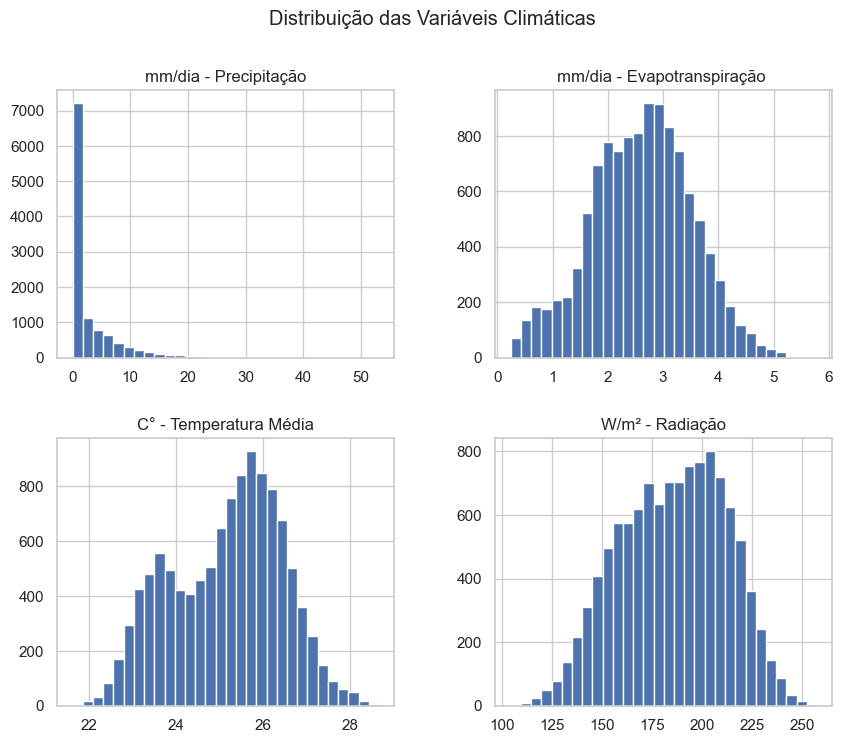

In [28]:
variaveis_climaticas.hist(
    bins=30,
    figsize=(10,8)
)

plt.suptitle("Distribuição das Variáveis Climáticas")
plt.show()

## Distribuição das Variáveis Climáticas

Para analisar o comportamento das variáveis climáticas ao longo da série histórica, foram construídos histogramas para precipitação, evapotranspiração, temperatura média e radiação.

O histograma da precipitação apresentou forte assimetria positiva, com grande concentração de valores próximos de zero e poucos eventos de chuva intensa. Esse comportamento indica a ocorrência de muitos dias sem precipitação e poucos episódios de chuva significativa, característica típica de regiões semiáridas.

Além disso, a distribuição da precipitação não apresenta formato aproximadamente normal, evidenciando forte assimetria e presença de eventos extremos. Esse padrão é comum em séries temporais de precipitação em regiões semiáridas, onde a ocorrência de chuvas é irregular e concentrada em poucos eventos.

A evapotranspiração apresentou distribuição relativamente equilibrada, com valores concentrados próximos da média e menor presença de valores extremos, indicando maior estabilidade ao longo do tempo.

A temperatura média apresentou distribuição aproximadamente normal, com baixa variabilidade e valores concentrados em torno da média, refletindo a estabilidade térmica da região.

A radiação solar apresentou distribuição relativamente simétrica, com valores concentrados em uma faixa moderada, indicando incidência solar relativamente constante ao longo da série histórica.

De forma geral, os histogramas reforçam que a principal variabilidade climática da região está associada à precipitação, enquanto temperatura, evapotranspiração e radiação apresentam comportamento mais estável.


In [29]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração ',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [30]:
dados.columns = dados.columns.str.strip()

In [31]:
dados = dados.rename(columns={
    "Data": "data",
    "mm/dia - Precipitação": "precipitacao",
    "mm/dia - Evapotranspiração": "evapotranspiracao",
    "C° - Temperatura Média": "temperatura_media",
    "W/m² - Radiação": "radiacao"
})

In [32]:
dados.columns

Index(['data', 'precipitacao', 'evapotranspiracao', 'temperatura_media',
       'radiacao'],
      dtype='str')

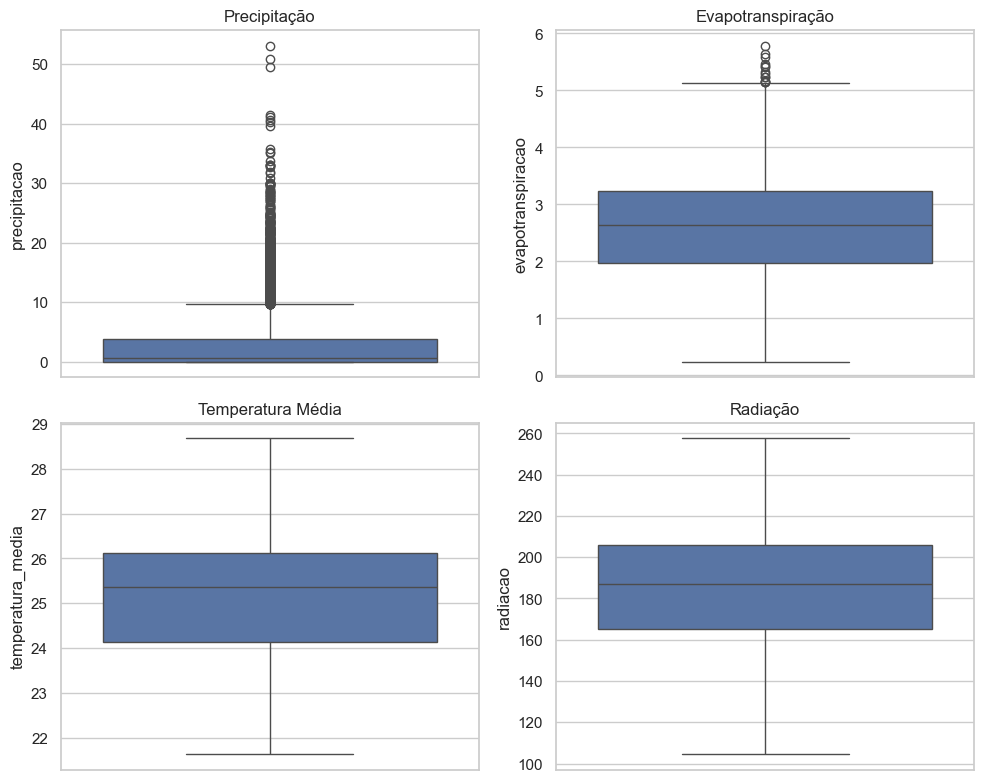

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))

sns.boxplot(y=dados["precipitacao"], ax=axes[0,0])
axes[0,0].set_title("Precipitação")

sns.boxplot(y=dados["evapotranspiracao"], ax=axes[0,1])
axes[0,1].set_title("Evapotranspiração")

sns.boxplot(y=dados["temperatura_media"], ax=axes[1,0])
axes[1,0].set_title("Temperatura Média")

sns.boxplot(y=dados["radiacao"], ax=axes[1,1])
axes[1,1].set_title("Radiação")

plt.tight_layout()
plt.show()

## Análise por Boxplots das Variáveis Climáticas

Foram construídos boxplots individuais para as variáveis precipitação, evapotranspiração, temperatura média e radiação, com o objetivo de avaliar a dispersão dos dados, a mediana, os quartis e a presença de valores extremos.

Esta interpretação refere-se ao **recorte de 5 municípios do Semiárido Paraibano**, conforme definido no enunciado do estudo (a base disponibilizada já representa esse recorte).

A variável precipitação apresentou forte assimetria e grande quantidade de outliers, indicando a ocorrência de muitos dias sem chuva e poucos eventos de precipitação intensa. Esse comportamento é característico de regiões semiáridas, onde a chuva ocorre de forma irregular ao longo do tempo.

A evapotranspiração apresentou variabilidade moderada e distribuição relativamente equilibrada, sugerindo maior estabilidade quando comparada à precipitação.

A temperatura média apresentou baixa dispersão e distribuição mais concentrada, indicando estabilidade térmica ao longo da série histórica.

A radiação apresentou variabilidade moderada, com distribuição relativamente regular, indicando incidência solar relativamente constante na região.

De forma geral, os boxplots reforçam que a principal variabilidade climática da região está associada à precipitação, enquanto temperatura, evapotranspiração e radiação apresentam comportamento mais estável.

# Etapa 1 — Análise Exploratória dos Dados Climáticos

## Objetivo

Realizar a **análise exploratória** de uma série histórica correspondente ao **recorte de 5 municípios do Semiárido Paraibano** (período **1984–2014**), caracterizando o clima da região e a variabilidade climática por meio de:

- estatística descritiva (média, mediana/quartis, desvio padrão, variância, mínimo e máximo);
- coeficiente de variação;
- tabelas e gráficos (histogramas e **boxplots**).

## Observação sobre o recorte por municípios

O enunciado do estudo considera um recorte de **5 municípios**. Entretanto, o arquivo disponibilizado neste projeto contém apenas a série temporal (coluna de data + variáveis climáticas), **sem coluna de município/cidade/estação**. Assim, o recorte municipal **já está embutido** na base (pré-processamento) e a análise exploratória aqui é feita sobre essa série resultante.

---

## Preparação dos Dados

Inicialmente, a base de dados foi importada para o ambiente Python utilizando a biblioteca **Pandas**. A coluna de datas foi convertida para o formato `datetime`, permitindo a manipulação temporal dos dados.

---

## Entregáveis desta etapa

Ao final desta etapa, são apresentados:

- tabelas de estatística descritiva e quartis;
- medidas de dispersão (variância e coeficiente de variação);
- gráficos de distribuição (histogramas);
- gráficos de dispersão e identificação de outliers (boxplots);
- interpretação textual dos principais padrões observados.